In [64]:
import pandas as pd


In [65]:
!pip install imageio-ffmpeg

In [66]:
import imageio_ffmpeg as ffmpeg

print(ffmpeg.get_ffmpeg_exe())

C:\Users\anish\AppData\Local\Programs\Python\Python312\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


In [67]:
import imageio_ffmpeg as ffmpeg
import subprocess

input_file = r"C:\Users\anish\Downloads\WhatsApp Audio 2026-06-25 at 3.40.53 PM.mp4"
output_file = "voice.wav"

subprocess.run([
    ffmpeg.get_ffmpeg_exe(),
    "-i", input_file,
    "-ac", "1",
    "-ar", "16000",
    output_file
])

print("Conversion completed")

Conversion completed


In [68]:
import os

print(os.path.exists("voice.wav"))

True


In [69]:
import librosa

audio, sr = librosa.load("voice.wav", sr=16000)

print("Loaded successfully")
print("Sample Rate =", sr)
print("Number of Samples =", len(audio))

Loaded successfully
Sample Rate = 16000
Number of Samples = 1404928


In [70]:
duration = len(audio) / sr

print("Duration =", round(duration, 2), "seconds")


Duration = 87.81 seconds


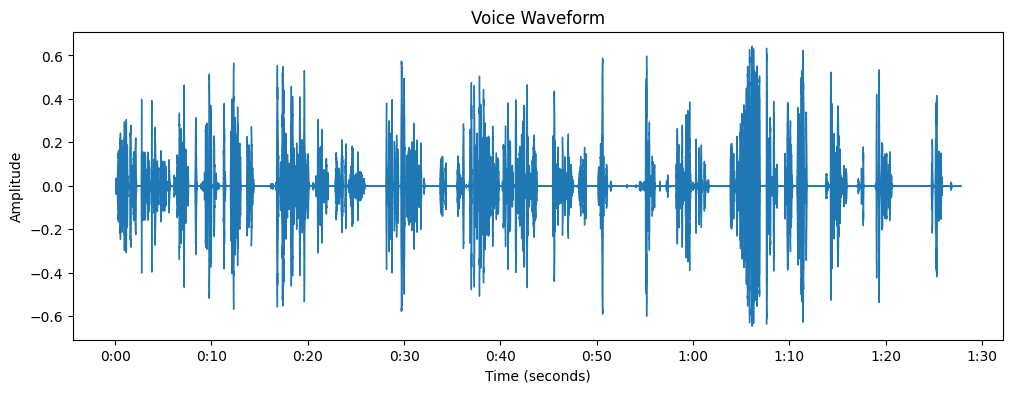

In [71]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(12,4))
librosa.display.waveshow(audio, sr=sr)

plt.title("Voice Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [72]:
import numpy as np

energy = np.mean(audio ** 2)

print("Energy =", energy)

Energy = 0.0021476012


In [73]:
f0, voiced_flag, voiced_probs = librosa.pyin(
    audio,
    fmin=75,
    fmax=600
)

import numpy as np

pitch = np.nanmean(f0)

print("Average Pitch =", pitch, "Hz")

Average Pitch = 213.90172836250733 Hz


In [74]:
mfccs = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)

print("MFCC Shape =", mfccs.shape)

MFCC Shape = (13, 2745)


In [75]:
import numpy as np

mfcc_mean = np.mean(mfccs, axis=1)

print("MFCC Mean Features:")
print(mfcc_mean)
print("Length =", len(mfcc_mean))

MFCC Mean Features:
[-434.1489       80.718155      3.315477      8.20449     -10.107977
  -10.864594    -11.88498      -7.7243032    -8.895528     -6.271012
   -0.98602086   -7.240262     -3.8374524 ]
Length = 13


In [76]:
import numpy as np

feature_vector = np.concatenate([
    [pitch],
    [energy],
    mfcc_mean
])

print("Feature Vector Length =", len(feature_vector))
print(feature_vector)

Feature Vector Length = 15
[ 2.13901728e+02  2.14760122e-03 -4.34148895e+02  8.07181549e+01
  3.31547689e+00  8.20448971e+00 -1.01079769e+01 -1.08645945e+01
 -1.18849802e+01 -7.72430325e+00 -8.89552784e+00 -6.27101183e+00
 -9.86020863e-01 -7.24026203e+00 -3.83745241e+00]
